In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid")

In [8]:
df = pd.read_csv('/content/crop_yield.csv')

In [9]:
print("--- 1. Initial Dataset Shape & Info ---")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
print(df.info())

--- 1. Initial Dataset Shape & Info ---
Total Rows: 19689, Total Columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB
None


In [10]:
print("\n--- First 5 Rows of Raw Data ---")
print(df.head())


--- First 5 Rows of Raw Data ---
           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           2051.4    75755.32     246.76     0.238333  
3           2051.4  1870661.52    6093.36  5238.051739  
4           2051.4   165500.63     539.09     0.420909  



--- Visual 1: Distribution of Crop Yields (Raw Data) ---


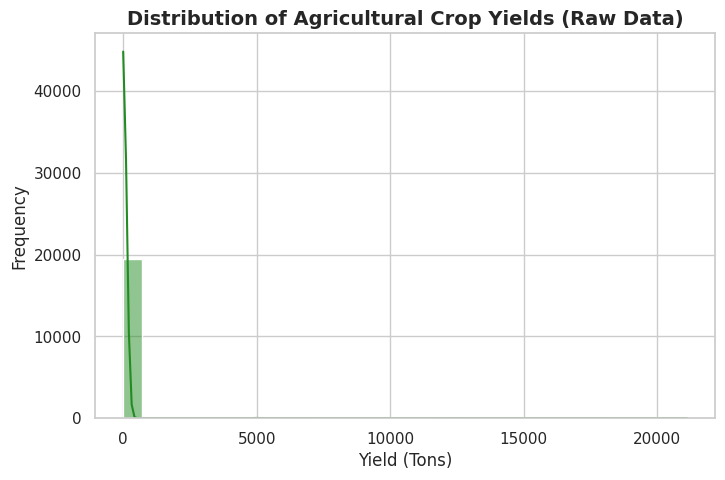

In [11]:
print("\n--- Visual 1: Distribution of Crop Yields (Raw Data) ---")
plt.figure(figsize=(8, 5))
sns.histplot(df["Yield"], kde=True, color="forestgreen", bins=30)
plt.title("Distribution of Agricultural Crop Yields (Raw Data)", fontsize=14, weight="bold")
plt.xlabel("Yield (Tons)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show() # Display the plot
plt.close()


--- Visual 2: Box Plot for Outlier Detection across Crop Types (Raw Data) ---


/tmp/ipykernel_678/4075352391.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


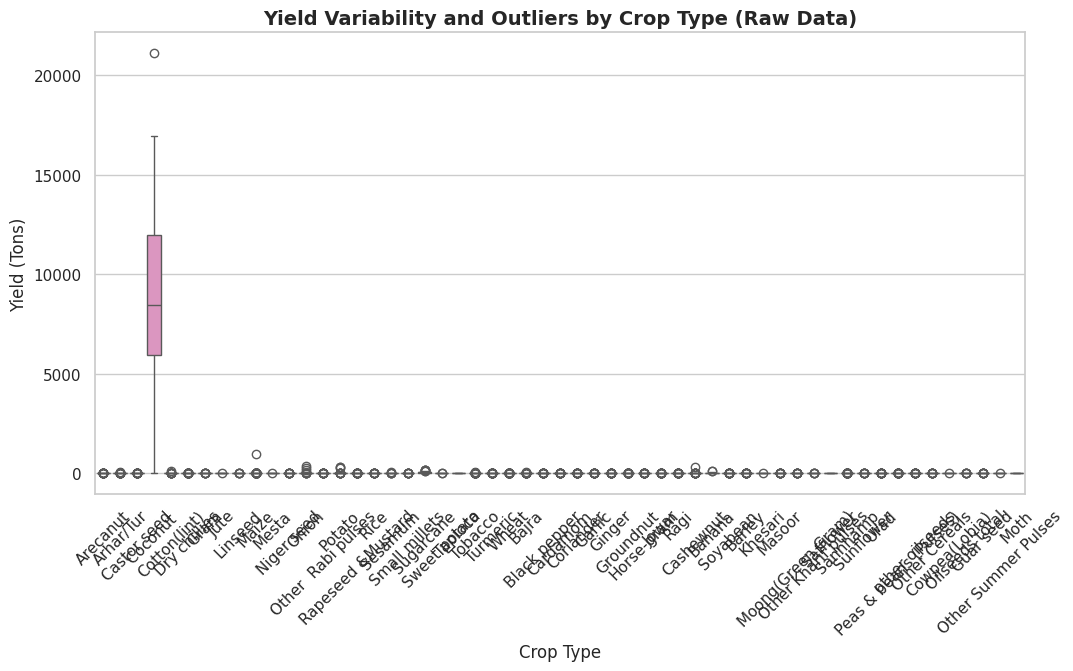

In [12]:
print("\n--- Visual 2: Box Plot for Outlier Detection across Crop Types (Raw Data) ---")
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="Crop", y="Yield", data=df, palette="Set2"
)
plt.title("Yield Variability and Outliers by Crop Type (Raw Data)", fontsize=14, weight="bold")
plt.xticks(rotation=45)
plt.xlabel("Crop Type", fontsize=12)
plt.ylabel("Yield (Tons)", fontsize=12)
plt.show() # Display the plot
plt.close()


--- Visual 3: Correlation Heatmap (Raw Data) ---


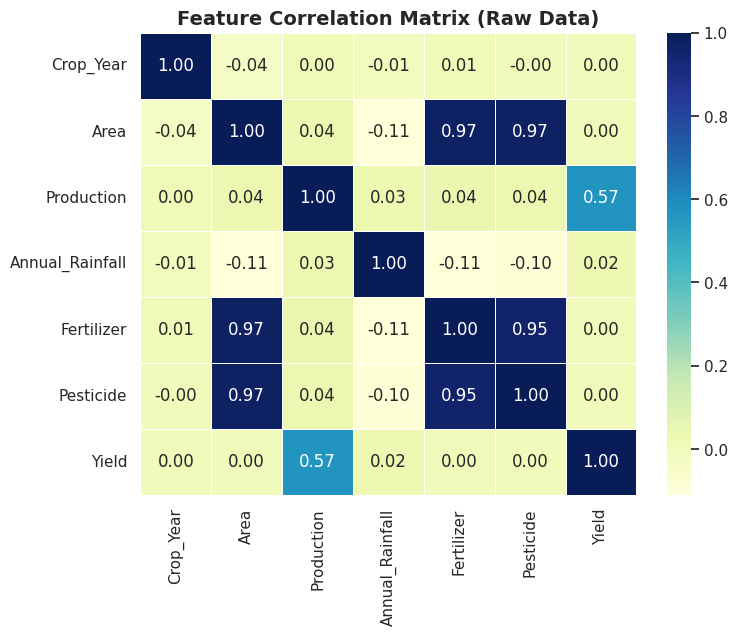

In [13]:
print("\n--- Visual 3: Correlation Heatmap (Raw Data) ---")
numeric_cols_raw = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
corr_matrix_raw = numeric_cols_raw.corr()
sns.heatmap(
    corr_matrix_raw, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5
)
plt.title("Feature Correlation Matrix (Raw Data)", fontsize=14, weight="bold")
plt.show() # Display the plot
plt.close()

In [14]:
print("\n--- 2. Checking Missing Values ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


--- 2. Checking Missing Values ---
Series([], dtype: int64)


In [15]:
df_cleaned = df.dropna()
print(f"Rows remaining after cleaning: {df_cleaned.shape[0]}")

Rows remaining after cleaning: 19689


In [16]:
print("\n--- 3. Descriptive Statistics (Numerical Summary) ---")
desc_stats = df_cleaned.describe()
print(desc_stats)


--- 3. Descriptive Statistics (Numerical Summary) ---
          Crop_Year          Area    Production  Annual_Rainfall  \
count  19689.000000  1.968900e+04  1.968900e+04     19689.000000   
mean    2009.127584  1.799266e+05  1.643594e+07      1437.755177   
std        6.498099  7.328287e+05  2.630568e+08       816.909589   
min     1997.000000  5.000000e-01  0.000000e+00       301.300000   
25%     2004.000000  1.390000e+03  1.393000e+03       940.700000   
50%     2010.000000  9.317000e+03  1.380400e+04      1247.600000   
75%     2015.000000  7.511200e+04  1.227180e+05      1643.700000   
max     2020.000000  5.080810e+07  6.326000e+09      6552.700000   

         Fertilizer     Pesticide         Yield  
count  1.968900e+04  1.968900e+04  19689.000000  
mean   2.410331e+07  4.884835e+04     79.954009  
std    9.494600e+07  2.132874e+05    878.306193  
min    5.417000e+01  9.000000e-02      0.000000  
25%    1.880146e+05  3.567000e+02      0.600000  
50%    1.234957e+06  2.421900e+0

In [17]:
numeric_cols = df_cleaned.select_dtypes(include=[np.number])
print("\n--- Feature Skewness ---")
print(numeric_cols.skew())


--- Feature Skewness ---
Crop_Year          -0.162656
Area               21.858218
Production         19.299193
Annual_Rainfall     2.131785
Fertilizer         13.412599
Pesticide          25.635746
Yield              12.785265
dtype: float64


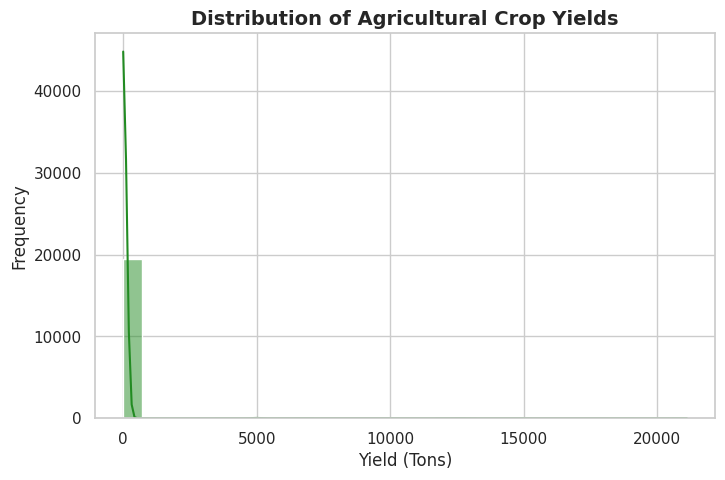

In [18]:
# 4. GENERATING REPORT VISUALIZATIONS

# Visual 1: Distribution of Crop Yields
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned["Yield"], kde=True, color="forestgreen", bins=30)
plt.title("Distribution of Agricultural Crop Yields", fontsize=14, weight="bold")
plt.xlabel("Yield (Tons)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.savefig("yield_distribution.png", dpi=300, bbox_inches="tight")
plt.show() # Display the plot
plt.close()

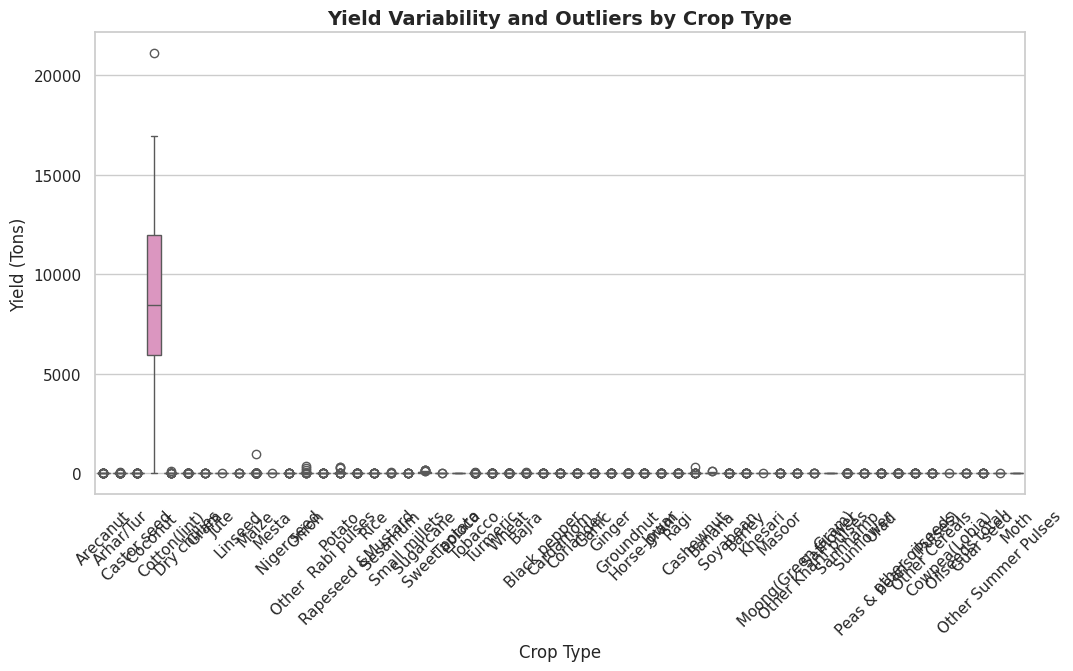

In [21]:
# Visual 2: Box Plot for Outlier Detection across Crop Types
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="Crop", y="Yield", data=df_cleaned, palette="Set2", hue="Crop", legend=False
)
plt.title("Yield Variability and Outliers by Crop Type", fontsize=14, weight="bold")
plt.xticks(rotation=45)
plt.xlabel("Crop Type", fontsize=12)
plt.ylabel("Yield (Tons)", fontsize=12)
plt.show() # Display the plot
plt.close()

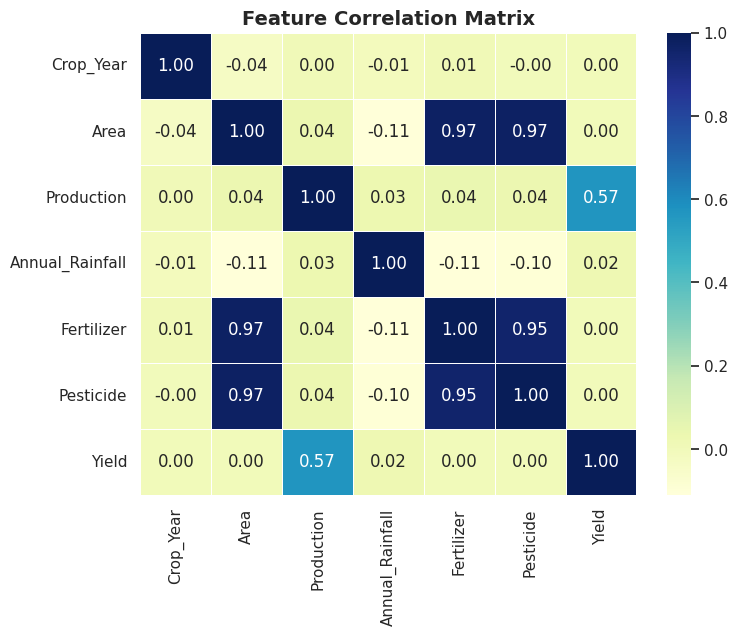


[SUCCESS] Data cleaning complete and all visualization charts saved locally!


In [20]:
# Visual 3: Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = numeric_cols.corr()
sns.heatmap(
    corr_matrix, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5
)
plt.title("Feature Correlation Matrix", fontsize=14, weight="bold")
plt.show() # Display the plot
plt.close()

print(
    "\n[SUCCESS] Data cleaning complete and all visualization charts saved locally!"
)

In [22]:
# Calculate total production by state
production_by_state = df_cleaned.groupby('State')['Production'].sum().reset_index()

# Calculate total overall production
total_overall_production = production_by_state['Production'].sum()

# Calculate percentage contribution
production_by_state['Percentage_Contribution'] = (production_by_state['Production'] / total_overall_production) * 100

# Sort by percentage contribution for better readability
production_by_state = production_by_state.sort_values(by='Percentage_Contribution', ascending=False)

print("\n--- Percentage of Yield Contribution by State ---")
display(production_by_state)


--- Percentage of Yield Contribution by State ---


,State,Production,Percentage_Contribution
13,Kerala,129700649853,40.079649
24,Tamil Nadu,78051759253,24.119287
12,Karnataka,63772797366,19.706851
0,Andhra Pradesh,26076218605,8.057983
29,West Bengal,8941179120,2.762972
27,Uttar Pradesh,4442585302,1.372832
2,Assam,3637714928,1.124114
6,Goa,2193998349,0.677982
15,Maharashtra,1878564915,0.580508
14,Madhya Pradesh,834490323,0.257871


### 5. Statistical Analysis of Yield by Season

In [23]:
# Perform statistical analysis of 'Yield' by 'Season'
yield_by_season_stats = df_cleaned.groupby('Season')['Yield'].describe()

print("\n--- Statistical Analysis of Yield by Season ---")
display(yield_by_season_stats)


--- Statistical Analysis of Yield by Season ---


,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
Autumn,414.0,3.917482,48.620326,0.156875,0.688333,1.091677,1.879097,989.870000
Kharif,8232.0,2.482002,9.016510,0.000000,0.537147,0.924226,1.655000,381.420000
Rabi,5742.0,1.988518,3.870516,0.000000,0.590000,0.902660,1.649474,80.268000
Summer,1195.0,2.997370,5.848808,0.000000,0.799321,1.673750,2.671786,69.366667
Whole Year,3717.0,412.995463,1987.425927,0.000000,0.912500,4.295122,16.770000,21105.000000
Winter,389.0,5.287267,12.971744,0.113000,0.440000,1.545333,2.487222,68.230000
